# SVGP Evaluation

In [10]:
# Celda 1 — Imports + paths + helpers

import os
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# libiomp5md.dll, but found libiomp5md.dll already initialized. PROBLEM with OpenMP runtime!
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"  # UNSAFE workaround, only used for experimentation.

# Para que se vean en notebook
%matplotlib inline

# ==== RUTAS (AJUSTA SI ES NECESARIO) ====

# MODEL_PATH   = "logs/svgp_dyn.pt"
# ROLLOUTS_PATH = "logs/rollouts_all.npz"

MODEL_PATH    = "logs_2drones/svgp_dyn_2drones.pt"
ROLLOUTS_PATH = "logs_2drones/rollouts_all_2drones.npz"


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TEST_FRAC = 0.2
PRED_BATCH = 4096

# Activa esto si quieres evaluar también varianza (más lento)
COMPUTE_VAR = False

# Activa esto si quieres una curva de aprendizaje re-entrenando incrementalmente
DO_LEARNING_CURVE = True
LC_INIT_STEPS = 200
LC_ONLINE_STEPS = 30
LC_SIZES = [300, 800, 1500, 3000, 6000, 10000, 15000]  # ajusta a tu N


def _dtype_from_str(s: str) -> torch.dtype:
    s = str(s).lower()
    if "float64" in s or "double" in s:
        return torch.float64
    return torch.float32


def load_rollouts(path: str):
    npz = np.load(path, allow_pickle=True)
    if "Z" not in npz.files or "dX" not in npz.files:
        raise ValueError(f"El .npz debe contener 'Z' y 'dX'. Encontré: {npz.files}")
    Z = np.asarray(npz["Z"], dtype=np.float32)
    dX = np.asarray(npz["dX"], dtype=np.float32)
    return Z, dX


def train_test_split_time(Z: np.ndarray, Y: np.ndarray, test_frac: float = 0.2):
    N = Z.shape[0]
    n_test = int(math.ceil(N * test_frac))
    n_train = N - n_test
    return (Z[:n_train], Y[:n_train]), (Z[n_train:], Y[n_train:])


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))


def mae(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    return np.mean(np.abs(y_true - y_pred), axis=0)


def r2(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2, axis=0) + 1e-12
    return 1.0 - (ss_res / ss_tot)
    

In [11]:
# Celda 2 — Cargar modelo + wrapper de predicción (batch o legacy) 

# Intentamos importar SVGP.py (ajusta sys.path si tu estructura es distinta)
try:
    from SVGP import OnlineSVGPBatch, OnlineSVGP1D
except Exception:
    import sys
    # Si tu SVGP.py está dentro de model_based/
    sys.path.append(os.path.abspath("model_based"))
    from SVGP import OnlineSVGPBatch, OnlineSVGP1D


class PredictorWrapper:
    """
    Wrapper unificado para predecir mean/var de dX.
    mean,var: np.ndarray shape (N, out_dim)
    """
    def __init__(self, bundle: dict, device: str = "cpu"):
        self.bundle = bundle
        self.device = torch.device(device)
        self.dtype = _dtype_from_str(bundle.get("dtype", "float32"))
        self.gp_type = bundle.get("gp_type", "batch")

        self.gp_batch = None
        self.gp_list = None

        if self.gp_type == "batch" and bundle.get("gp", None) is not None:
            gp_b = bundle["gp"]
            self.gp_batch = OnlineSVGPBatch(
                input_dim=int(gp_b.get("input_dim", 9)),
                output_dim=int(gp_b.get("output_dim", 6)),
                kernel=bundle.get("kernel", "RBF"),
                lr=float(bundle.get("lr", 0.01)),
                batch_size=int(bundle.get("batch_size", 256)),
                num_inducing=int(bundle.get("num_inducing", 256)),
                init_train_steps=int(bundle.get("init_train_steps", 800)),
                device=str(self.device),
                dtype=self.dtype,
            )
            self.gp_batch.load_from_bundle(gp_b)
            self.in_dim = int(self.gp_batch.input_dim)
            self.out_dim = int(self.gp_batch.output_dim)
        else:
            gps_bundle = bundle.get("gps", None)
            if gps_bundle is None:
                raise RuntimeError("Checkpoint legacy pero no trae 'gps'.")
            self.gp_list = []
            for i in range(len(gps_bundle)):
                gp = OnlineSVGP1D(
                    input_dim=int(bundle.get("input_dim", 9)) if "input_dim" in bundle else 9,
                    kernel=bundle.get("kernel", "RBF"),
                    lr=float(bundle.get("lr", 0.01)),
                    batch_size=int(bundle.get("batch_size", 256)),
                    num_inducing=int(bundle.get("num_inducing", 256)),
                    init_train_steps=int(bundle.get("init_train_steps", 800)),
                    device=str(self.device),
                    dtype=self.dtype,
                )
                gp.load_from_bundle(gps_bundle[i])
                self.gp_list.append(gp)
            self.in_dim = int(bundle.get("input_dim", 9)) if "input_dim" in bundle else 9
            self.out_dim = len(self.gp_list)

    @torch.no_grad()
    def predict(self, Z: np.ndarray, return_var: bool = True, batch_size: int = 4096):
        N, D = Z.shape
        if D != self.in_dim:
            raise ValueError(f"Z tiene D={D} pero el modelo espera D={self.in_dim}")

        means, vars_ = [], []
        for i in range(0, N, batch_size):
            zb = torch.as_tensor(Z[i:i+batch_size], device=self.device, dtype=self.dtype)

            if self.gp_batch is not None:
                m, v = self.gp_batch.predict_torch(zb, return_var=return_var)  # (B,T)
                m_np = m.detach().cpu().numpy()
                v_np = v.detach().cpu().numpy()
            else:
                m_list, v_list = [], []
                for gp in self.gp_list:
                    mi, vi = gp.predict_torch(zb, return_var=return_var)  # (B,)
                    m_list.append(mi)
                    v_list.append(vi)
                m_np = torch.stack(m_list, dim=-1).detach().cpu().numpy()
                v_np = torch.stack(v_list, dim=-1).detach().cpu().numpy()

            means.append(m_np)
            vars_.append(v_np)

        return np.concatenate(means, axis=0), np.concatenate(vars_, axis=0)


# Cargar bundle
bundle = torch.load(MODEL_PATH, map_location="cpu")
pred = PredictorWrapper(bundle, device=DEVICE)

print("Modelo cargado:")
print("  gp_type:", bundle.get("gp_type", None))
print("  kernel:", bundle.get("kernel", None))
print("  in_dim:", pred.in_dim, "out_dim:", pred.out_dim)

Modelo cargado:
  gp_type: batch
  kernel: RBF
  in_dim: 18 out_dim: 12


In [12]:
# Celda 3 — Cargar rollouts, split temporal, predecir y métricas

Z, dX = load_rollouts(ROLLOUTS_PATH)
(Ztr, Ytr), (Zte, Yte) = train_test_split_time(Z, dX, test_frac=TEST_FRAC)

print(f"Datos: total={Z.shape[0]} train={Ztr.shape[0]} test={Zte.shape[0]}  in_dim={Z.shape[1]} out_dim={dX.shape[1]}")

Yhat, Yvar = pred.predict(Zte, return_var=COMPUTE_VAR, batch_size=PRED_BATCH)

rmse_vec = rmse(Yte, Yhat)
mae_vec  = mae(Yte, Yhat)
r2_vec   = r2(Yte, Yhat)

print("\nMétricas en TEST:")
for i in range(pred.out_dim):
    print(f"  dim {i:02d}: RMSE={rmse_vec[i]:.6f}  MAE={mae_vec[i]:.6f}  R2={r2_vec[i]:.4f}")

Datos: total=30000 train=24000 test=6000  in_dim=18 out_dim=12

Métricas en TEST:
  dim 00: RMSE=0.000034  MAE=0.000024  R2=0.9962
  dim 01: RMSE=0.000033  MAE=0.000022  R2=0.9968
  dim 02: RMSE=0.000135  MAE=0.000094  R2=0.9971
  dim 03: RMSE=0.007927  MAE=0.005520  R2=0.2304
  dim 04: RMSE=0.006422  MAE=0.005088  R2=0.0798
  dim 05: RMSE=0.006653  MAE=0.005003  R2=0.6552
  dim 06: RMSE=0.000042  MAE=0.000031  R2=0.9970
  dim 07: RMSE=0.000037  MAE=0.000025  R2=0.9949
  dim 08: RMSE=0.000147  MAE=0.000103  R2=0.9974
  dim 09: RMSE=0.008197  MAE=0.005666  R2=0.1683
  dim 10: RMSE=0.006799  MAE=0.005416  R2=0.0809
  dim 11: RMSE=0.006886  MAE=0.005026  R2=0.6871


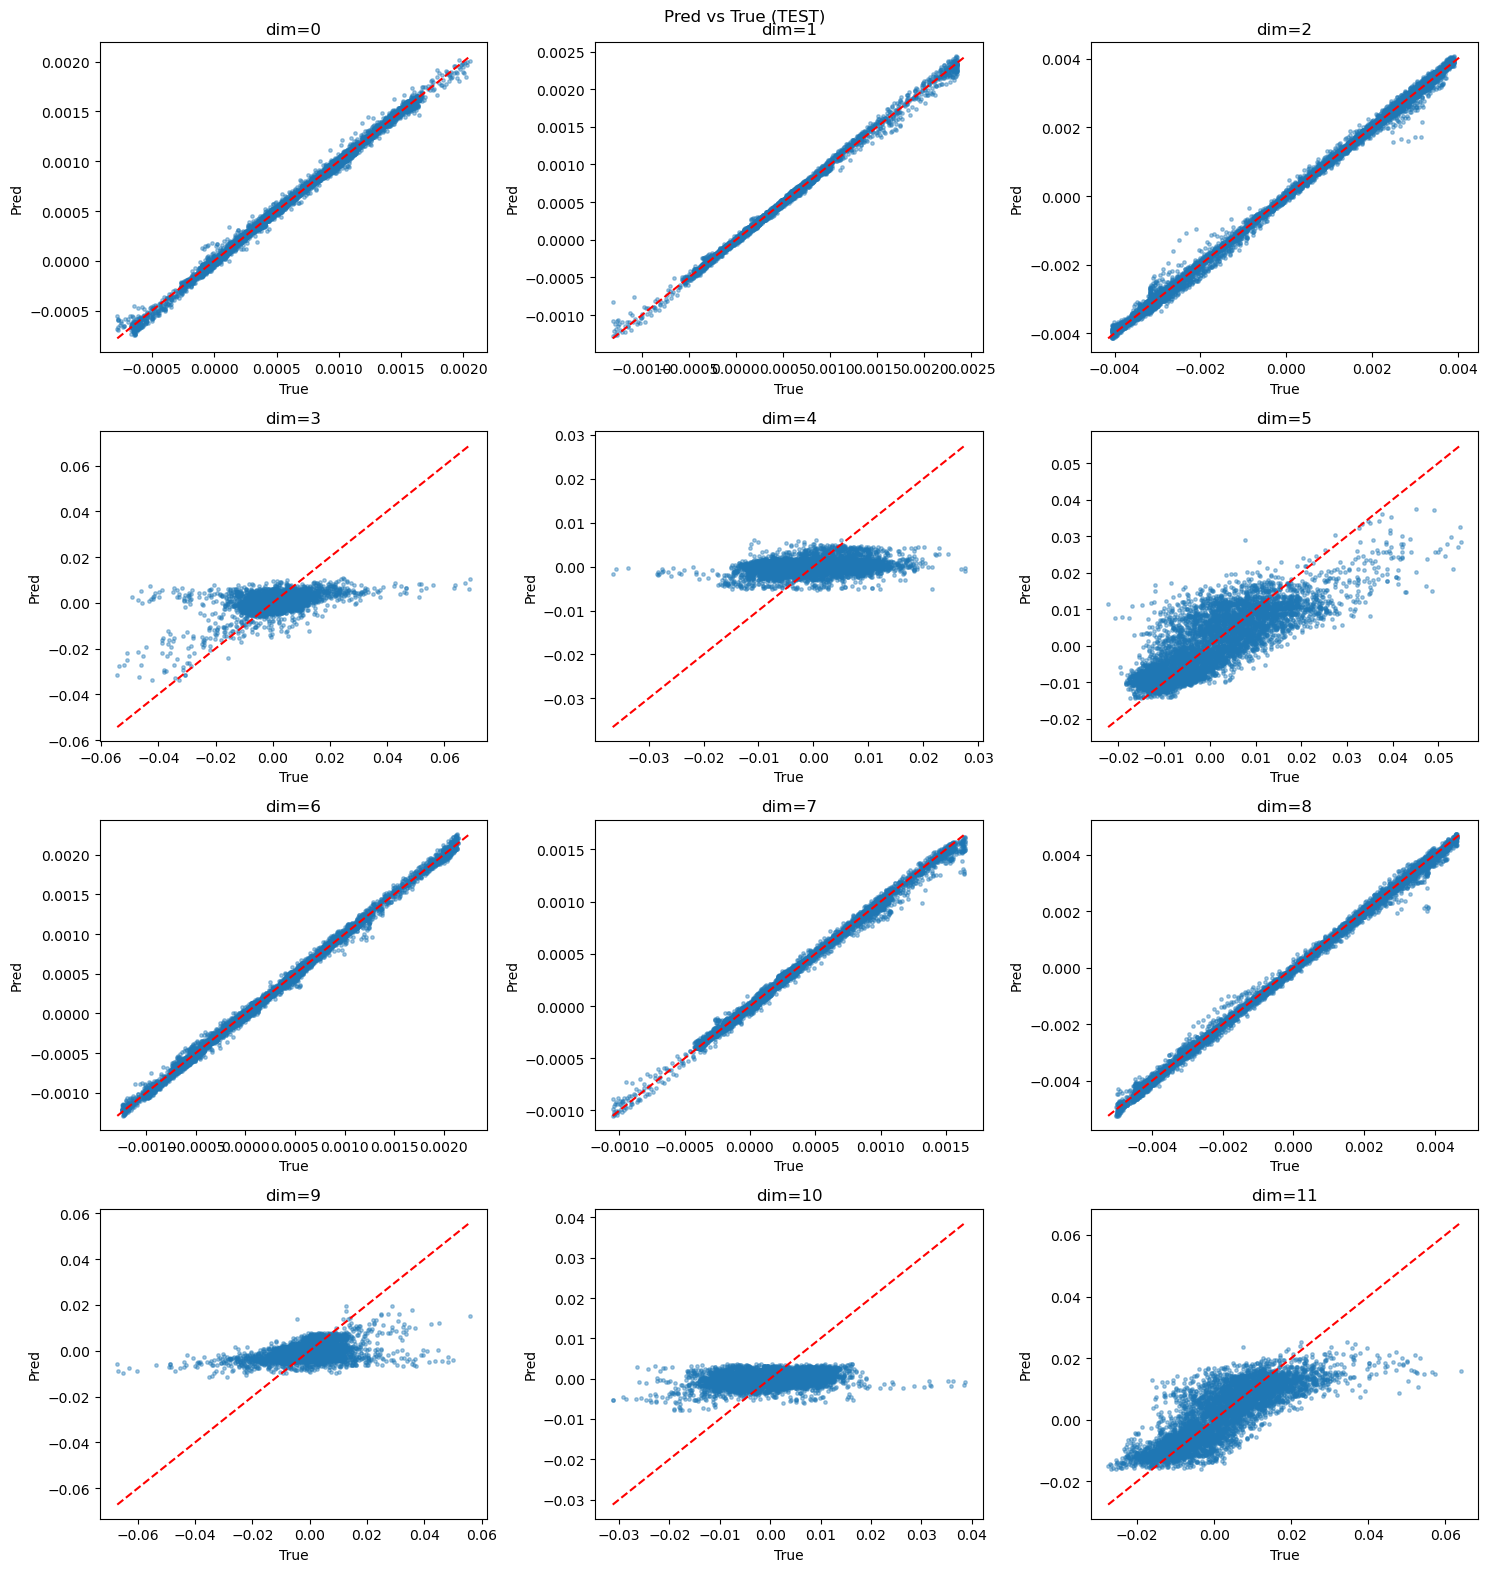

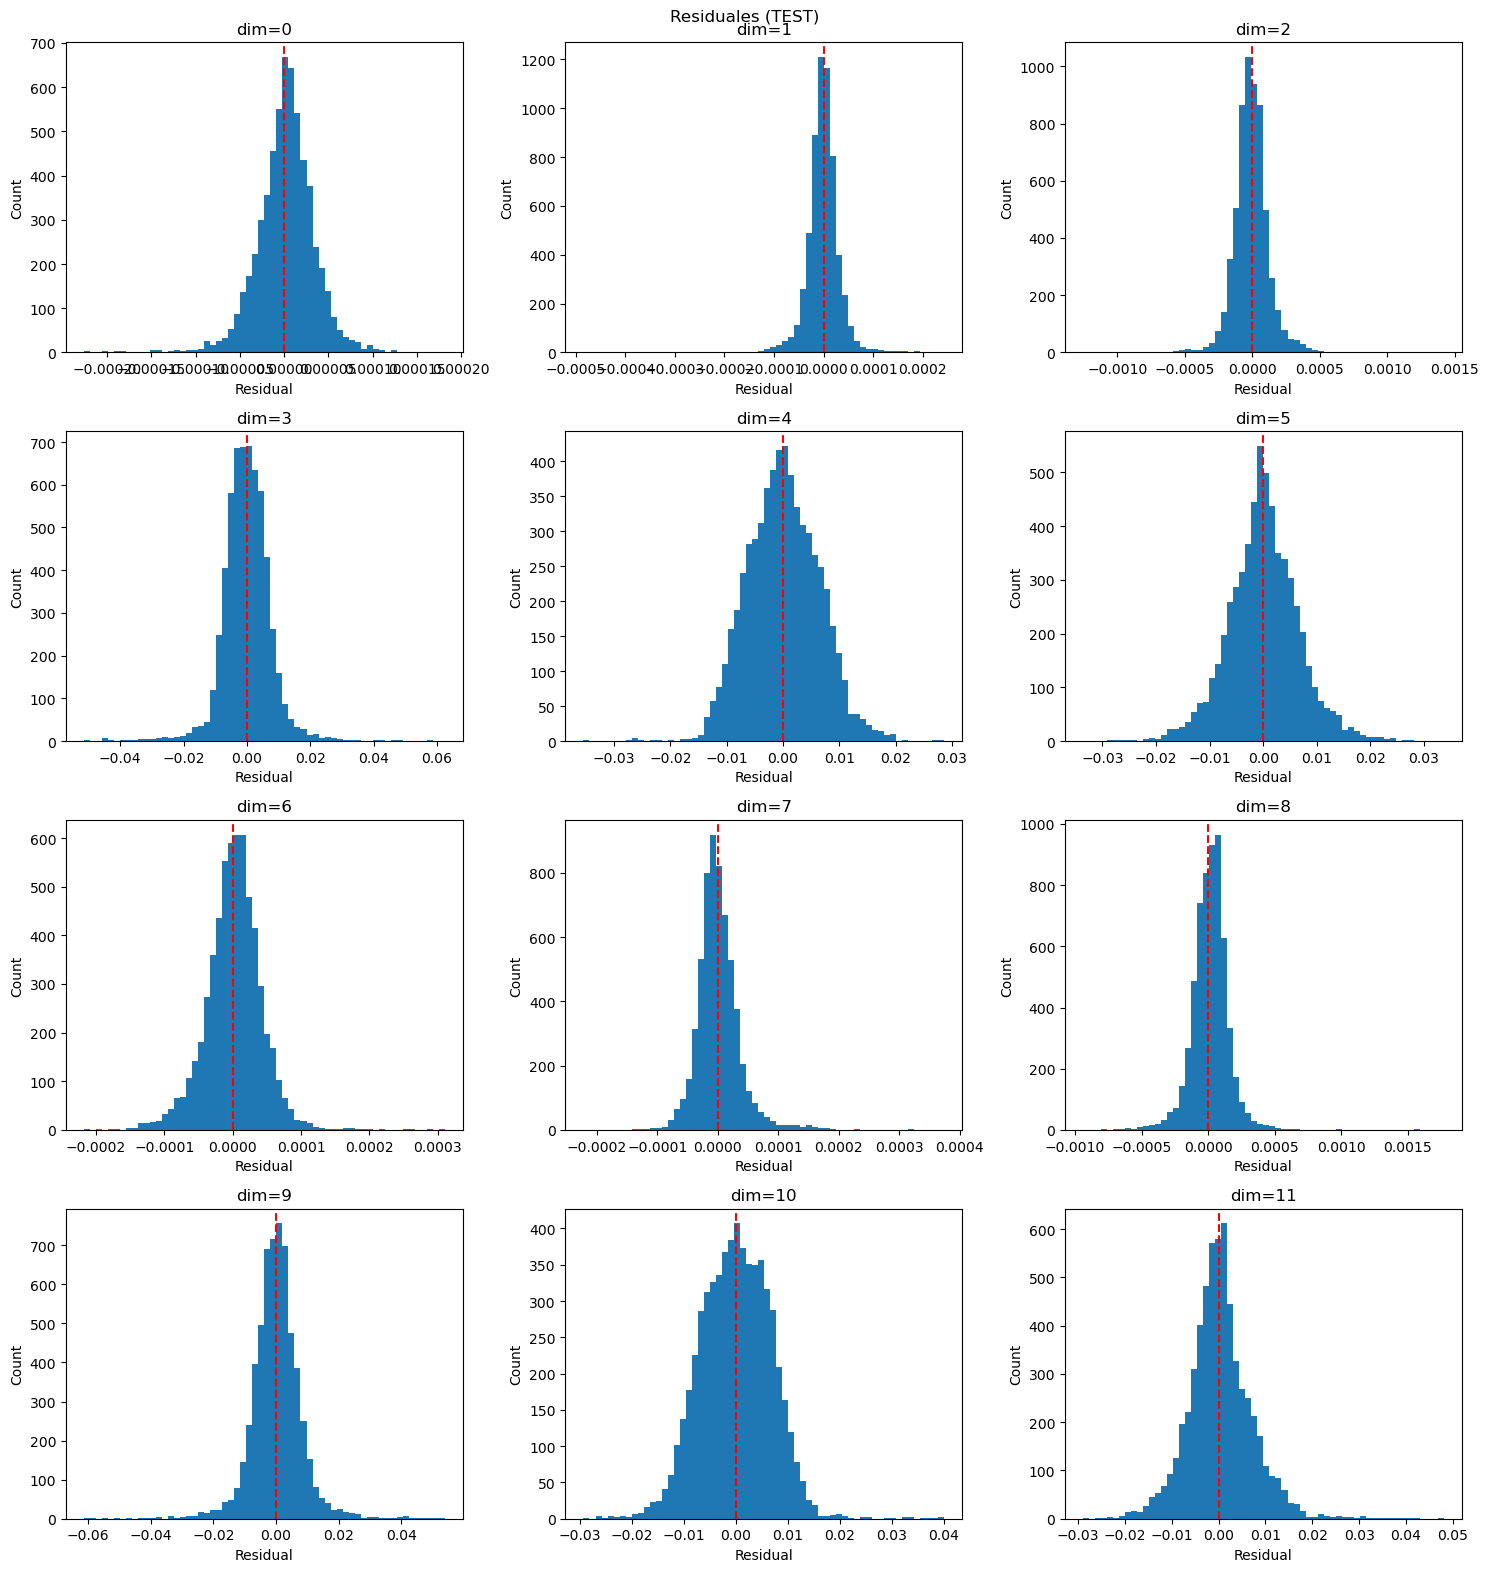

In [13]:
# Celda 4 — Gráficos principales (inline)

def plot_grid_pred_vs_true(Yte, Yhat, ncols=3, suptitle="Pred vs True"):
    out_dim = Yte.shape[1]
    nrows = int(math.ceil(out_dim / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.atleast_2d(axes)

    for d in range(nrows * ncols):
        ax = axes[d // ncols, d % ncols]
        if d >= out_dim:
            ax.axis("off")
            continue

        ax.scatter(Yte[:, d], Yhat[:, d], s=6, alpha=0.4)
        lo = float(min(Yte[:, d].min(), Yhat[:, d].min()))
        hi = float(max(Yte[:, d].max(), Yhat[:, d].max()))
        ax.plot([lo, hi], [lo, hi], "r--", label="Ideal")
        ax.set_xlabel("True")
        ax.set_ylabel("Pred")
        ax.set_title(f"dim={d}")

    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()


def plot_grid_residual_hist(Yte, Yhat, ncols=3, suptitle="Histogramas de residuales (true - pred)"):
    # Para cada dimensión de salida, muestra un histograma de los residuales (Yte - Yhat).
    # Esto ayuda a ver si hay sesgos sistemáticos o colas pesadas en los errores de predicción.
    # Si el modelo es bueno, esperamos que los residuales estén centrados alrededor de 0 y tengan una distribución relativamente simétrica.
    # Si hay sesgo, el histograma estará desplazado hacia un lado. Si hay colas pesadas, veremos barras altas lejos de 0. Si el modelo es perfecto, el histograma sería un pico en 0.
    # Sesgo: histograma desplazado hacia un lado (residuales positivos o negativos)
    # Colas pesadas: barras altas lejos de 0 (muchos errores grandes)
    # Sesgo significa que el modelo sistemáticamente sobreestima o subestima esa dimensión.
    # Colas pesadas indican que hay muchos casos donde el error de predicción es grande, lo cual puede ser problemático para control o planificación.
    # Cómo se corrige el sesgo? Si es un sesgo constante, se puede ajustar el modelo para que prediga un valor promedio más cercano a la media real. Si el sesgo depende de la entrada, puede ser necesario usar un modelo más complejo o agregar características adicionales.
    
    out_dim = Yte.shape[1]
    nrows = int(math.ceil(out_dim / ncols))

    resid = (Yte - Yhat)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.atleast_2d(axes)

    for d in range(nrows * ncols):
        ax = axes[d // ncols, d % ncols]
        if d >= out_dim:
            ax.axis("off")
            continue

        # Add a vertical line at x=0 to see bias
        ax.axvline(0, color="r", linestyle="--", label="Zero Residual")

        ax.hist(resid[:, d], bins=60)
        ax.set_xlabel("Residual")
        ax.set_ylabel("Count")
        ax.set_title(f"dim={d}")


    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()

plot_grid_pred_vs_true(Yte, Yhat, ncols=3, suptitle="Pred vs True (TEST)")
plot_grid_residual_hist(Yte, Yhat, ncols=3, suptitle="Residuales (TEST)")

In [ ]:
# Celda 5 (opcional) — Curva de aprendizaje (cómo mejora con más datos)

if DO_LEARNING_CURVE:
    # re-entrenamos un SVGPBatch desde cero para ver curva (no usa tu checkpoint)
    from SVGP import OnlineSVGPBatch

    out_dim = Ytr.shape[1]
    in_dim = Ztr.shape[1]

    # filtros básicos de tamaños
    sizes = sorted(set([s for s in LC_SIZES if 0 < s <= Ztr.shape[0]]))
    if len(sizes) == 0:
        raise ValueError("LC_SIZES inválido para el tamaño de entrenamiento.")

    gp = OnlineSVGPBatch(
        input_dim=in_dim,
        output_dim=out_dim,
        kernel=bundle.get("kernel", "RBF"),
        lr=float(bundle.get("lr", 0.01)),
        batch_size=int(bundle.get("batch_size", 256)),
        num_inducing=int(bundle.get("num_inducing", 256)),
        init_train_steps=int(LC_INIT_STEPS),
        device=DEVICE,
        dtype=torch.float32,
    )

    used = []
    rmse_list = []

    # Fit inicial
    s0 = sizes[0]
    gp.fit(Ztr[:s0], Ytr[:s0])
    pred0, _ = gp.predict_torch(torch.as_tensor(Zte, device=DEVICE, dtype=torch.float32), return_var=False)
    rmse_list.append(rmse(Yte, pred0.detach().cpu().numpy()))
    used.append(s0)

    prev = s0
    for s in sizes[1:]:
        gp.add_data(Ztr[prev:s], Ytr[prev:s], online_steps=int(LC_ONLINE_STEPS))
        predk, _ = gp.predict_torch(torch.as_tensor(Zte, device=DEVICE, dtype=torch.float32), return_var=False)
        rmse_list.append(rmse(Yte, predk.detach().cpu().numpy()))
        used.append(s)
        prev = s

    rmse_arr = np.stack(rmse_list, axis=0)  # (K,out_dim)
    rmse_mean = np.mean(rmse_arr, axis=1)

    plt.figure()
    plt.plot(used, rmse_mean, marker="o")
    plt.xlabel("# transiciones usadas para entrenar")
    plt.ylabel("RMSE promedio (sobre dims)")
    plt.title("Curva de aprendizaje (RMSE vs datos)")
    plt.tight_layout()
    plt.show()

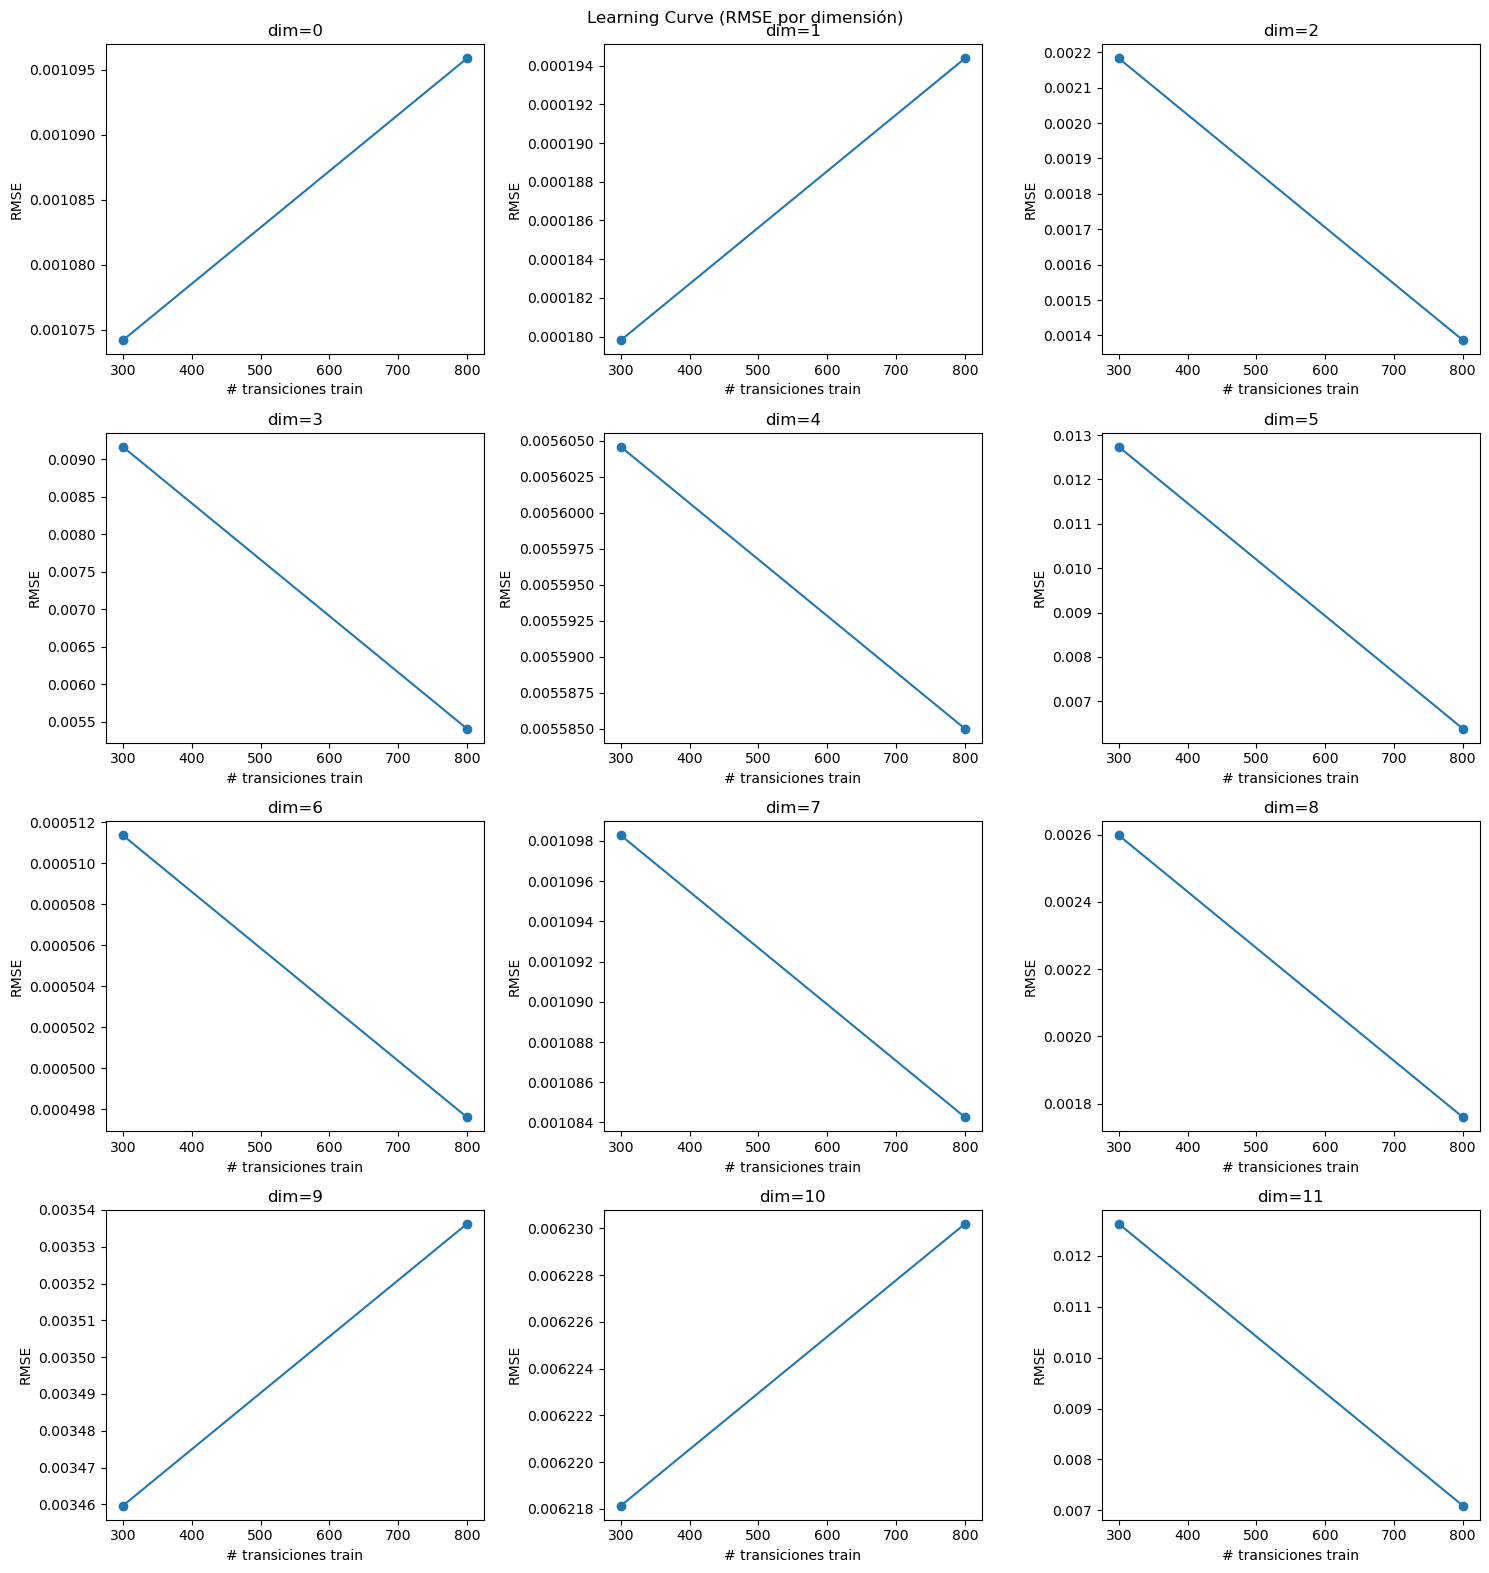

In [ ]:
def plot_learning_curve_per_dim(used, rmse_list, ncols=3, suptitle="Curva de aprendizaje (RMSE por dimensión)"):
    """
    used: lista de tamaños [n1, n2, ...]
    rmse_list: lista de vectores rmse (out_dim,) por cada tamaño
    """
    rmse_arr = np.stack(rmse_list, axis=0)  # (K, out_dim)
    out_dim = rmse_arr.shape[1]
    nrows = int(math.ceil(out_dim / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.atleast_2d(axes)

    for d in range(nrows * ncols):
        ax = axes[d // ncols, d % ncols]
        if d >= out_dim:
            ax.axis("off")
            continue

        ax.plot(used, rmse_arr[:, d], marker="o")
        ax.set_xlabel("# transiciones train")
        ax.set_ylabel("RMSE")
        ax.set_title(f"dim={d}")

    fig.suptitle(suptitle)
    fig.tight_layout()
    plt.show()


def simulate_learning(
    Z_train: np.ndarray,
    Y_train: np.ndarray,
    Z_test: np.ndarray,
    Y_test: np.ndarray,
    kernel: str,
    device: str,
    out_dim: int,
    in_dim: int,
    num_inducing: int,
    batch_size: int,
    lr: float,
    init_steps: int,
    online_steps: int,
    sizes: list,
):
    """
    Entrena un OnlineSVGPBatch desde cero con un prefijo de datos y luego hace
    updates incrementales, midiendo RMSE sobre un conjunto de test fijo.

    Returns:
      used_list: [n_points_1, n_points_2, ...]
      rmse_list: [rmse_vec_1, rmse_vec_2, ...] donde rmse_vec tiene shape (out_dim,)
    """
    # Import (ajusta sys.path si tu SVGP.py está en otra carpeta)
    try:
        from SVGP import OnlineSVGPBatch
    except Exception:
        import os, sys
        sys.path.append(os.path.abspath("model_based"))
        from SVGP import OnlineSVGPBatch

    # Sanitizar sizes
    Ntr = Z_train.shape[0]
    sizes = [int(s) for s in sizes if int(s) > 0]
    sizes = sorted(set(sizes))
    sizes = [s for s in sizes if s <= Ntr]
    if len(sizes) == 0:
        raise ValueError(f"sizes inválido: {sizes}. N_train={Ntr}")

    # Crear GP desde cero
    gp = OnlineSVGPBatch(
        input_dim=in_dim,
        output_dim=out_dim,
        kernel=kernel,
        lr=lr,
        batch_size=batch_size,
        num_inducing=num_inducing,
        init_train_steps=int(init_steps),
        device=device,
        dtype=torch.float32,
    )

    used_list = []
    rmse_list = []

    # helper RMSE por dim
    def _rmse_vec(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))

    # Fit inicial con sizes[0]
    s0 = sizes[0]
    gp.fit(Z_train[:s0], Y_train[:s0])

    with torch.no_grad():
        pred0, _ = gp.predict_torch(
            torch.as_tensor(Z_test, device=device, dtype=torch.float32),
            return_var=False
        )
    rmse_list.append(_rmse_vec(Y_test, pred0.detach().cpu().numpy()))
    used_list.append(s0)

    # Incremental: añadir más datos y entrenar online
    prev = s0
    for s in sizes[1:]:
        Z_new = Z_train[prev:s]
        Y_new = Y_train[prev:s]
        gp.add_data(Z_new, Y_new, online_steps=int(online_steps))

        with torch.no_grad():
            predk, _ = gp.predict_torch(
                torch.as_tensor(Z_test, device=device, dtype=torch.float32),
                return_var=False
            )
        rmse_list.append(_rmse_vec(Y_test, predk.detach().cpu().numpy()))
        used_list.append(s)

        prev = s

    return used_list, rmse_list


DO_LEARNING_CURVE = True

if DO_LEARNING_CURVE:
    used, rmses = simulate_learning(
        Z_train=Ztr,
        Y_train=Ytr,
        Z_test=Zte,
        Y_test=Yte,
        kernel=bundle.get("kernel", "RBF"),
        device=DEVICE,
        out_dim=pred.out_dim,
        in_dim=pred.in_dim,
        num_inducing=int(bundle.get("num_inducing", 256)),
        batch_size=int(bundle.get("batch_size", 256)),
        lr=float(bundle.get("lr", 0.01)),
        init_steps=int(LC_INIT_STEPS),
        online_steps=int(LC_ONLINE_STEPS),
        sizes=list(LC_SIZES),
    )

    plot_learning_curve_per_dim(used, rmses, ncols=3, suptitle="Learning Curve (RMSE por dimensión)")

In [ ]:
def plot_data_maps_single_drone(
    Z_all,
    dX_all,
    ncols=3,
    max_points=20000,
    color_mode="delta",     # "delta" | "next" | "abs_err"
    dX_pred=None,           # necesario si color_mode="abs_err" (shape (N,6))
):
    """
    Para 1 dron:
      Z = [pos(3), vel(3), F(3)]   => (N,9)
      dX = [Δpos(3), Δvel(3)]      => (N,6)

    Gráficas (2x3):
      fila 1: x=F_axis, y=pos_prev_axis, color = Δpos_axis (o según color_mode)
      fila 2: x=F_axis, y=vel_prev_axis, color = Δvel_axis (o según color_mode)
    """
    Z_all = np.asarray(Z_all)
    dX_all = np.asarray(dX_all)

    if Z_all.shape[1] != 9 or dX_all.shape[1] != 6:
        print("Este graficador es solo para 1 dron (Z:9, dX:6). Saltando.")
        return

    N = Z_all.shape[0]
    if N > max_points:
        idx = np.random.choice(N, size=max_points, replace=False)
        Z = Z_all[idx]
        dX = dX_all[idx]
        if dX_pred is not None:
            dX_pred = np.asarray(dX_pred)[idx]
    else:
        Z = Z_all
        dX = dX_all
        if dX_pred is not None:
            dX_pred = np.asarray(dX_pred)

    X_prev = Z[:, 0:6]        # (N,6)
    F = Z[:, 6:9]             # (N,3)
    X_next = X_prev + dX      # (N,6)

    axes = ["x", "y", "z"]
    pos_idx = [0, 1, 2]
    vel_idx = [3, 4, 5]
    F_idx   = [0, 1, 2]

    # Selección de color
    if color_mode == "delta":
        C_pos = dX[:, 0:3]     # Δpos
        C_vel = dX[:, 3:6]     # Δvel
        title_suffix = "color = Δ"
    elif color_mode == "next":
        C_pos = X_next[:, 0:3]
        C_vel = X_next[:, 3:6]
        title_suffix = "color = X_next"
    elif color_mode == "abs_err":
        if dX_pred is None:
            raise ValueError("Para color_mode='abs_err' debes pasar dX_pred (N,6).")
        err = np.abs(dX - dX_pred)
        C_pos = err[:, 0:3]
        C_vel = err[:, 3:6]
        title_suffix = "color = |Δ_true - Δ_pred|"
    else:
        raise ValueError("color_mode debe ser: 'delta', 'next' o 'abs_err'.")

    fig, axs = plt.subplots(2, ncols, figsize=(5*ncols, 4*2))
    axs = np.atleast_2d(axs)

    # ---- POS ----
    for j, ax_name in enumerate(axes):
        ax = axs[0, j]
        x = F[:, F_idx[j]]
        y = X_prev[:, pos_idx[j]]
        c = C_pos[:, j]

        sc = ax.scatter(x, y, c=c, s=6, alpha=0.5)
        ax.set_xlabel(f"F_{ax_name}")
        ax.set_ylabel(f"pos_prev_{ax_name}")
        ax.set_title(f"{title_suffix}pos_{ax_name}")
        plt.colorbar(sc, ax=ax)

    # ---- VEL ----
    for j, ax_name in enumerate(axes):
        ax = axs[1, j]
        x = F[:, F_idx[j]]
        y = X_prev[:, vel_idx[j]]
        c = C_vel[:, j]

        sc = ax.scatter(x, y, c=c, s=6, alpha=0.5)
        ax.set_xlabel(f"F_{ax_name}")
        ax.set_ylabel(f"vel_prev_{ax_name}")
        ax.set_title(f"{title_suffix}vel_{ax_name}")
        plt.colorbar(sc, ax=ax)

    fig.suptitle("Mapas de datos (1 dron): (F_axis vs Xprev_axis)")
    fig.tight_layout()
    plt.show()

# por variación de estado
plot_data_maps_single_drone(Z, dX, color_mode="next")
# por estado siguiente
plot_data_maps_single_drone(Z, dX, color_mode="delta")
# o si quieres solo train:
# plot_data_maps_single_drone(Ztr, Ytr, ncols=3, max_points=20000)

Este graficador es solo para 1 dron (Z:9, dX:6). Saltando.
Este graficador es solo para 1 dron (Z:9, dX:6). Saltando.
